In [33]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import umap

import os
import sys
module_path = os.path.abspath(os.path.join('../..'))
if module_path not in sys.path:
    sys.path.append(module_path)
import random
from tqdm import tqdm

from src.data.data import get_ds, get_normalized_ds
from src.visualizations.umap_visualizer import UMAPLatent

In [34]:
class SiameseContrastiveLoss(torch.nn.Module):
    def __init__(self, m):
        super().__init__()
        self.m = m
    def forward(self, data, labels):
        batch_size = data.shape[0]
        rangeset = torch.arange(batch_size)
        all_combos = torch.combinations(rangeset)
        same_labels = all_combos[(labels[all_combos[:, 0]] == labels[all_combos[:, 1]]).nonzero()].squeeze()
        opposite_labels = all_combos[(labels[all_combos[:, 0]] != labels[all_combos[:, 1]]).nonzero()].squeeze()
        same_distances = torch.linalg.norm(data[same_labels][:, 0] - data[same_labels][:, 1], dim=1)
        opposite_distances = torch.linalg.norm(data[opposite_labels][:, 0] - data[opposite_labels][:, 1], dim=1)
        same_loss = 0.5*torch.sum(same_distances.pow(2))
        opposite_loss = 0.5*torch.sum(torch.max(torch.tensor(0), self.m - opposite_distances).pow(2))
        final = same_loss + opposite_loss
        return final

In [35]:
class Encoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super(Encoder, self).__init__()
        self.lstm1 = nn.LSTM(input_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.lstm2 = nn.LSTM(2 * hidden_dim, latent_dim, batch_first=True)
        self.dropout = nn.Dropout(0.2)
        
    def forward(self, x):
        x, (hidden, cell) = self.lstm1(x)
        x = self.dropout(x)
        x, (hidden, cell) = self.lstm2(x)
        return hidden[-1, :, :]

In [36]:
class EncoderTrainer(nn.Module):
    def __init__(self, models, train_ds, test_ds, num_variables, index_to_class, batch_size, lr, epochs):
        super(EncoderTrainer, self).__init__()
        self.models = models
        self.train_ds = train_ds   
        self.test_ds = test_ds
        self.num_variables = num_variables
        self.index_to_class = index_to_class
        self.batch_size = batch_size
        self.lr = lr
        self.epochs = epochs

        self.train_dataloader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
        self.test_dataloader = DataLoader(test_ds, len(test_ds), shuffle=False)

        self.opts = [torch.optim.Adam(self.models[i].parameters(), lr=lr) for i in range(num_variables)]

        self.scheds = [torch.optim.lr_scheduler.ExponentialLR(self.opts[i], 0.999) for i in range(num_variables)]
        
        self.contrastive_loss_fn = SiameseContrastiveLoss(m=1.0)

        self.contrastive_losses = [[] for _ in range(num_variables)]

    def train(self):
        for model in self.models:
            model.train()
        for epoch in tqdm(range(self.epochs)):
            for i in range(self.num_variables):
                for batch_idx, (data, labels) in enumerate(self.train_dataloader):
                    data = data[:, :, i].unsqueeze(2).float()
                    self.opts[i].zero_grad()
                    embeddings = self.models[i](data)
                    contrastive_loss = self.contrastive_loss_fn(embeddings, labels)
                    contrastive_loss.backward()
                    self.opts[i].step()
                self.scheds[i].step()
                self.contrastive_losses[i].append(contrastive_loss.item())

    def plot_contrastive_losses(self, variable=None):
        plt.figure()
        plt.title("Contrastive Losses")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")

        if variable:
            plt.plot(self.contrastive_losses[variable], label="Variable " + str(variable + 1))
        else:
            for i in range(self.num_variables):
                plt.plot(self.contrastive_losses[i], label="Variable " + str(i + 1))
        plt.legend()
        plt.show()

    def plot_latent_spaces(self):
        for data_matrix, labels in self.test_dataloader:
            for i in range(self.num_variables):
                plt.figure()
                inp = data_matrix[:, :, i].unsqueeze(2).float()
                with torch.no_grad():
                    embeddings = self.models[i](inp)

                    reducer = umap.UMAP()
                    embeddings_2d = reducer.fit_transform(embeddings)

                    string_labels = np.array([self.index_to_class[float(label)] for label in labels])
                    unique_labels = ["Standing", "Walking", "Running", "Badminton"]

                    handles, lbls = [], []
                    for label in unique_labels:
                        idx = np.where(string_labels == label)[0]
                        scatter = plt.scatter(embeddings_2d[idx, 0], embeddings_2d[idx, 1], label=label)
                        handles.append(scatter)
                        lbls.append(label)
                        
                    plt.legend(handles, lbls)
                    plt.title("Latent Space for Variable " + str(i + 1))
                    plt.show()
    

In [37]:
# Load in BasicMotions dataset
class_to_index={"standing":0, "running":1, "walking":2,"badminton":3}
index_to_class = {0:"Standing", 1:"Running", 2:"Walking", 3:"Badminton", 4:"Prototype"}

train_ds, test_ds = get_normalized_ds("/Users/bhaveshkalisetti/Desktop/mmbs/data/basicmotions/BasicMotions_TRAIN.ts", class_to_index), get_normalized_ds("/Users/bhaveshkalisetti/Desktop/mmbs/data/basicmotions/BasicMotions_TEST.ts", class_to_index)
len(train_ds)

40

In [38]:
encoders = torch.nn.ModuleList([Encoder(input_dim=1, hidden_dim=32, latent_dim=16) for _ in range(6)])
encoder_trainer = EncoderTrainer(
    models=encoders,
    train_ds=train_ds,
    test_ds=test_ds,
    num_variables=6,
    index_to_class=index_to_class,
    batch_size=40,
    lr=0.01,
    epochs=750,
)

In [39]:
encoder_trainer.train()

100%|██████████| 750/750 [03:43<00:00,  3.36it/s]


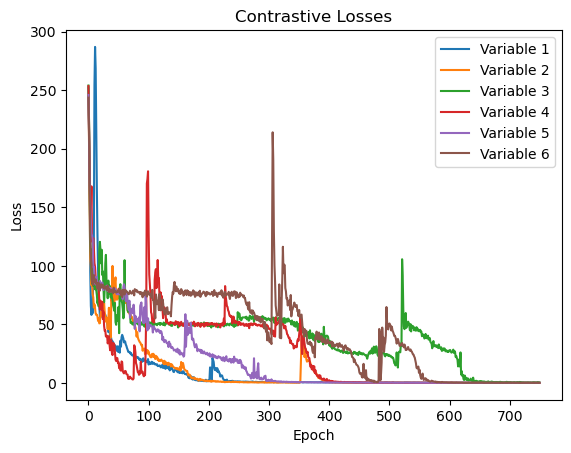

In [40]:
encoder_trainer.plot_contrastive_losses()

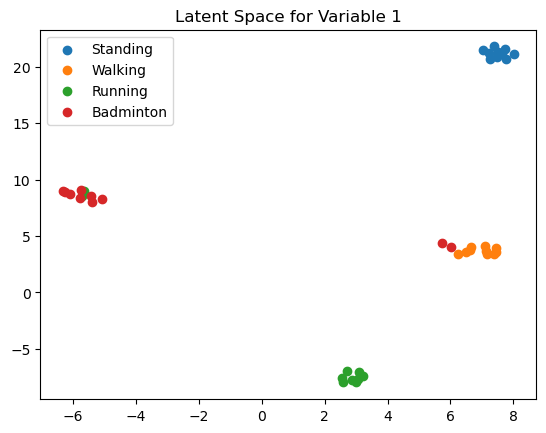

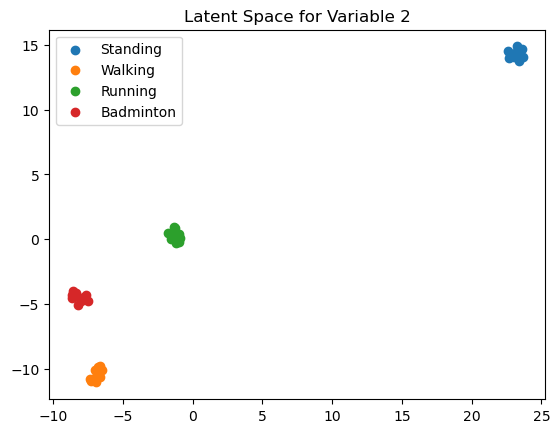

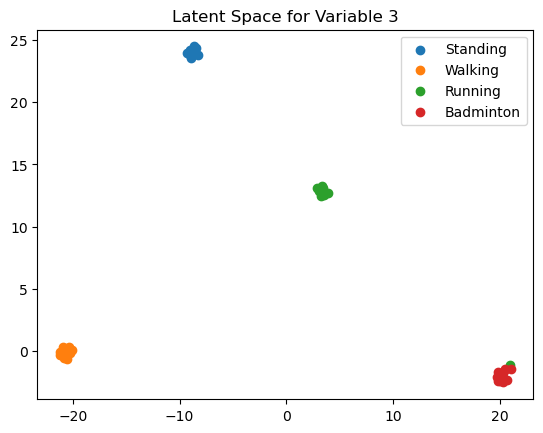

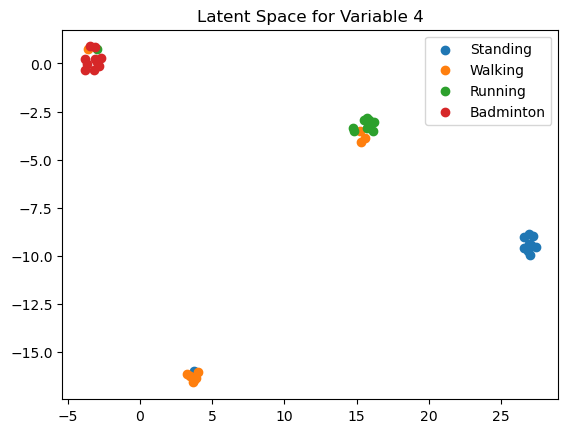

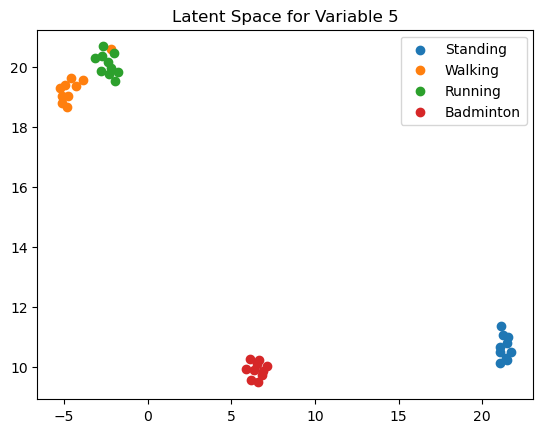

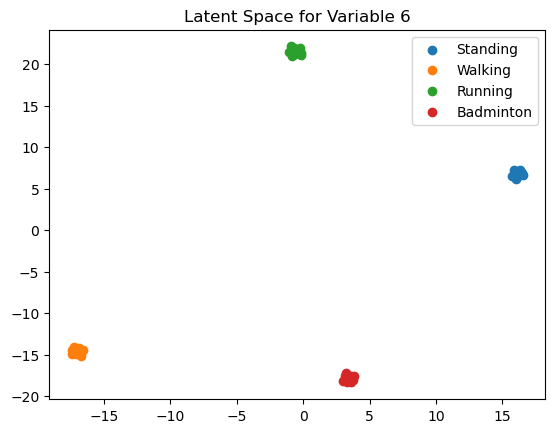

In [41]:
encoder_trainer.plot_latent_spaces()

In [43]:
save = True
if save:
    torch.save(encoder_trainer.state_dict(), "/Users/bhaveshkalisetti/Desktop/mmbs/models/basicmotions/new/encoder.dat")